### Estimation of CIR Process with a time series approach

$$
dr_t = a(b - r_t) \, dt + \sigma \sqrt{r_t} \, dW_t
$$

- a > 0 : speed or mean reversion coefficient
- $ b \in R $ : long term mean
- $ \sigma > 0 $ : volatility

From solving the CIR bond pricing PDE, we get that bond prices are given by: 

$$
P(t,T) = A(t,T) e^{-B(t,T)r_t}
$$

with 
$$
A(t,T) = \left( \frac{2h e^{\tfrac{(a+h)(T-t)}{2}}}{2h + (a+h)\left(e^{h(T-t)} - 1\right)} \right)^{\tfrac{2ab}{\sigma^2}}
$$

$$
B(t,T) = \frac{2\left(e^{h(T-t)} - 1\right)}{2h + (a+h)\left(e^{h(T-t)} - 1\right)}
$$

$$
h = \sqrt{a^2 + 2\sigma^2}
$$

We are going to use **OLS** to calibrate the CIR process to interest rates. We do this by first testing on a simulation where the parameters are known. This is NOT a cross sectional approach but rather a time series approach to calibration. It means we need a proxy for the interest rate (r) or risk free bond prices (P) for a set period of time, e.g. 1 year observed daily. 

Using Euler-Maruyama Scheme we can rewrite the problem as: 

This leads to the following equation:

$$
r_{t+\delta t} - r_t = k(\theta - r_t)\delta t + \sigma \sqrt{r_t} N(0, \delta t)
$$

Following some straightforward manipulations, it can be rewritten as:

$$
\frac{r_{t+\delta t} - r_t}{\sqrt{r_t}} = \frac{k\theta\delta t}{\sqrt{r_t}} - k\sqrt{r_t}\delta t + \sigma \sqrt{\delta t} N(0, 1)
$$

This can be interpreted as:

$$
y_i = \beta_1 z_{1,i} + \beta_2 z_{2,i} + \epsilon_i
$$

Where:

$$
y_i = \frac{r_{t+\delta t} - r_t}{\sqrt{r_t}}
$$

$$
\beta_1 = k\theta
$$

$$
\beta_2 = -k
$$

$$
z_{1,i} = \frac{\delta t}{\sqrt{r_t}}
$$

$$
z_{2,i} = \sqrt{r_t} \delta t
$$

$$
\epsilon_i = \sigma \sqrt{\delta t} N(0, 1)
$$


In [1]:
# import libraries
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# function to simulate paths
def simulate_cir(k, theta, sigma, r0, T, N):

    # populate an empty array
    dt = T / N
    interest_rate_paths = np.zeros(N+1)
    interest_rate_paths[0] = r0 
    for t in range(1, N+1):
        Z = np.random.randn()
        r = interest_rate_paths[t-1]
        interest_rate_paths[t] = r + k * (theta-r) * dt + sigma * np.sqrt(dt) * np.sqrt(max(0, r)) * Z    
    return interest_rate_paths

In [3]:
# function to estimate parameters
def ols_cir(data, dt):

    # define variables
    Nsteps = len(data)
    rs = data[:Nsteps - 1]  
    rt = data[1:Nsteps]
    
    # model initialization
    model = LinearRegression()

    # feature engineering to fit the theoretical model
    y = (rt - rs) / np.sqrt(rs)
    z1 = dt / np.sqrt(rs)
    z2 = dt * np.sqrt(rs)
    X = np.column_stack((z1, z2))

    # fit the model
    model = LinearRegression(fit_intercept=False)
    model.fit(X, y)

    # calculate the predicted values (y_hat), residuals and the parameters
    y_hat = model.predict(X)
    residuals = y - y_hat
    beta1 = model.coef_[0]        
    beta2 = model.coef_[1]

    # get the parameter of interest for CIR
    k0 = -beta2
    theta0 = beta1/k0
    sigma0 = np.std(residuals)/np.sqrt(dt)
    
    return k0, theta0, sigma0

In [4]:
k_true = 5 # True mean reversion speed
theta_true = 0.05  # True long-run mean
sigma_true = 0.03 # True volatility of interest rates
r0_true = 0.3 # True initial interest rate
T = 1  # Time horizon
N = 100  # Number of time steps
dt = T/N

# simulated path
np.random.seed(123)
series = simulate_cir(k_true, theta_true, sigma_true, r0_true, T, N)
estimates = ols_cir(series, dt)

# print results
print(f"The theoretical parameters are: k={k_true}, theta={theta_true}, sigma={sigma_true}")
print(f"The estimates are: k={round(estimates[0], 3)}, theta={round(estimates[1], 3)}, sigma={round(estimates[2], 3)}")

The theoretical parameters are: k=5, theta=0.05, sigma=0.03
The estimates are: k=5.078, theta=0.051, sigma=0.034


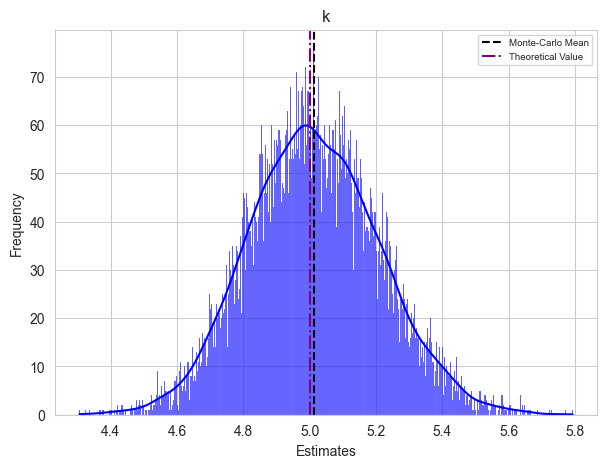

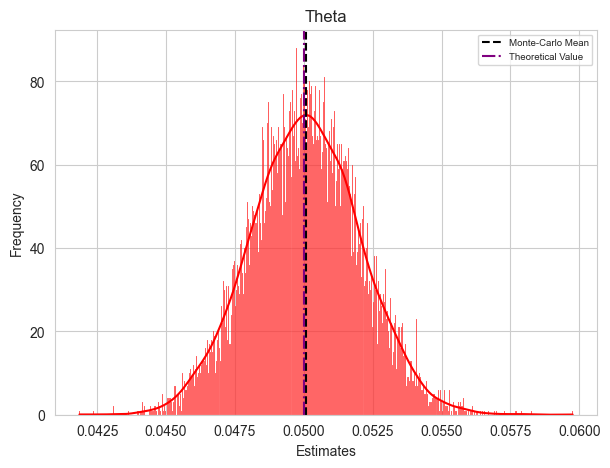

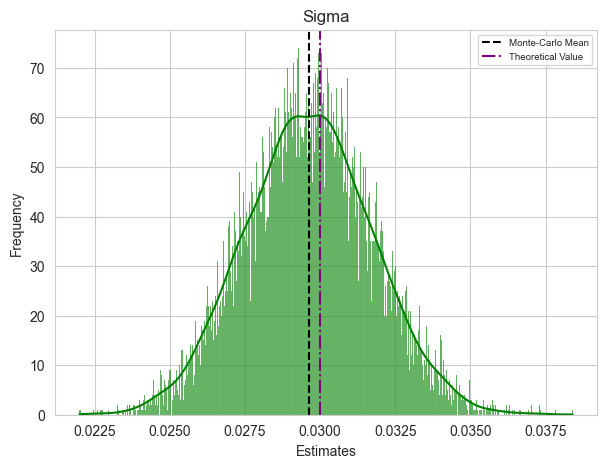

In [5]:
# define variables
n_scenarios = 10000
paths = np.zeros(shape=(n_scenarios, N+1))
OLS_estimates = np.zeros(shape=(n_scenarios,3))

# perform simulations
np.random.seed(123)
count = 0
while count < n_scenarios:
    # fill the array with the simulations
    series = simulate_cir(k_true, theta_true, sigma_true, r0_true, T, N)
    
    # Check if there's at least one negative number in the series
    if np.any(series < 0):
        # Calculate the value of the 99th percentile
        percentile_99 = np.percentile(series, 99)
        # Add the value of the 99th percentile to each element of the series
        series += percentile_99

    paths[count, :] = series
    
    # OLS estimation
    estimates = ols_cir(series, dt)
    OLS_estimates[count,:] = estimates
    
    # update counter
    count += 1

# plot of the estimates distributions
colours = ["blue", "red", "green"] 
parameters = ["k", "Theta", "Sigma"] 
real_values = [k_true, theta_true, sigma_true]

# Set the seaborn style
sns.set_style("whitegrid")
for i in range(3):  # Using range(3) for iterating over indices

    # Set up the plot
    plt.figure(figsize=(7, 5))
    sns.histplot(OLS_estimates[:, i], bins=500, color=colours[i], alpha=0.7, kde=True)

    # Plot mean as black dot line
    mean_estimate = np.mean(OLS_estimates[:, i])
    plt.axvline(mean_estimate, color="black", linestyle="--", label="Monte-Carlo Mean")

    # Plot specified value as purple dot line
    plt.axvline(real_values[i], color="purple", linestyle="-.", label="Theoretical Value")

    plt.xlabel("Estimates", fontsize="medium")
    plt.ylabel("Frequency", fontsize="medium")
    plt.title(parameters[i], fontsize="large")
    plt.legend(title_fontsize="small", fontsize="x-small")
    plt.show()